## Imports

In [53]:
import os

import seaborn as sns
from fastdtw import fastdtw

In [2]:
from utils.MOO_utilities import *

## Data

In [3]:
ORDER = ["SuperFuture", "Apples", "WorldNow", "Electronics123", "Photons", "SpaceNow", "PearPear",
         "PositiveCorrelation", "BetterTechnology", "ABCDE", "EnviroLike", "Moneymakers", "Fuel4",
         "MarsProject", "CPU-XYZ", "RoboticsX", "Lasers", "WaterForce", "SafeAndCare", "BetterTomorrow"]

In [4]:
dr = DataReader("./data/Bundle1")
dr.read_data()
old_data = dr.get_data()
assert len(old_data.keys()) == 20

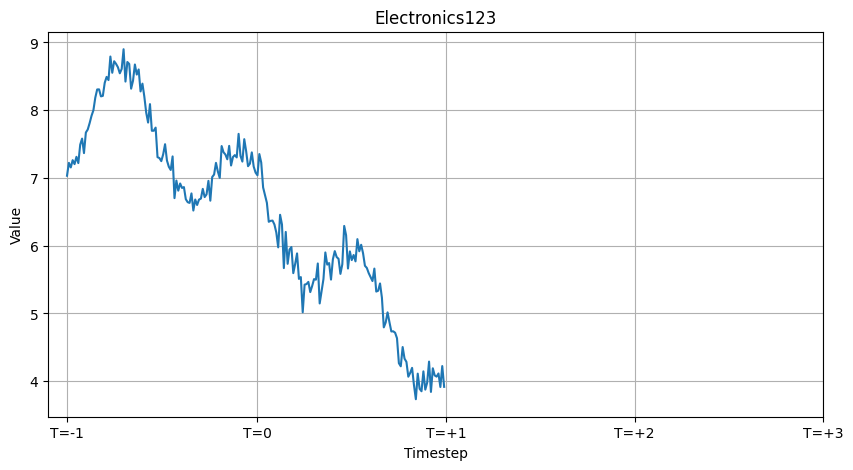

In [5]:
dr = DataReader("./data/Bundle2")
dr.read_data()
dr.plot()
data = dr.get_data()
assert len(data.keys()) == 20

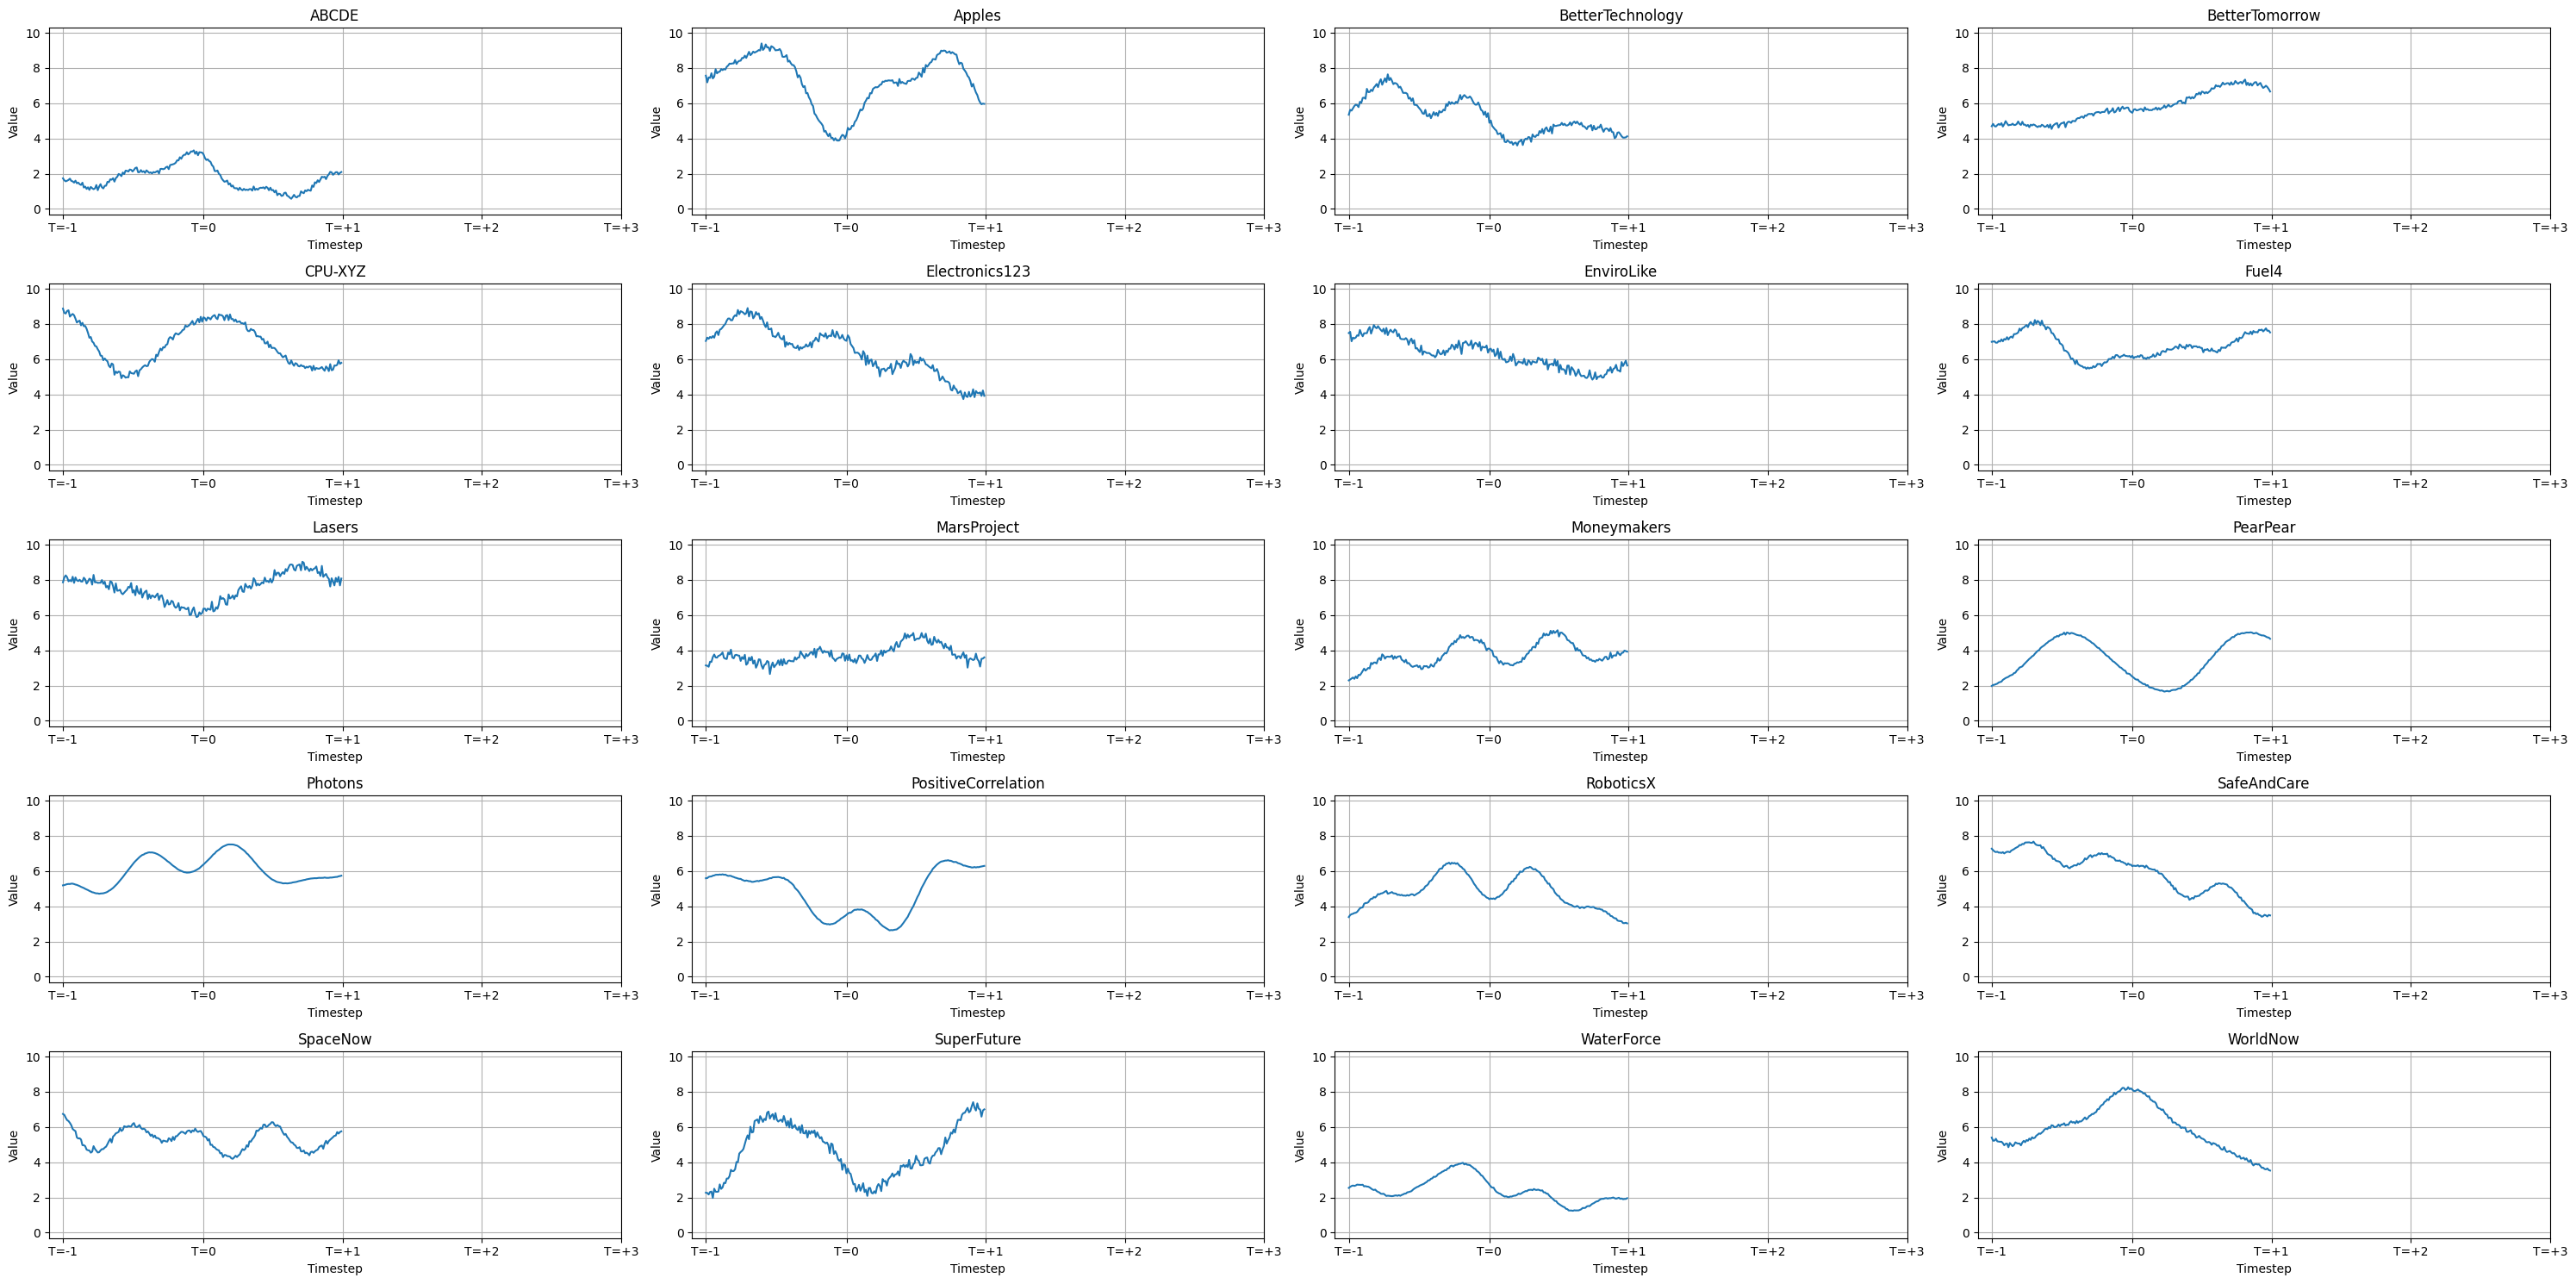

In [6]:
dr.plot_all(figsize=(30, 15), normalized_y=True)

In [7]:
ground_truth = {company_name: (np.arange(102, 202), data[company_name][101:]) for company_name in ORDER}

## Quality tests

### Regression

In [ ]:
regression_models = ["Linear", "Sinusoidal", "Complex Sinusoidal", "ARIMA", "XGBoost", "NODE"]

RMC = RegressionModelsCombined(old_data, window_size=50)
RMC.create_X_y(101)

RMC.train_linear()
linear_predictions = RMC.predict_linear()
RMC.train_sinusoidal()
sinusoidal_predictions = RMC.predict_sinusoidal()
RMC.train_complex_sinusoidal()
complex_sinusoidal_predictions = RMC.predict_complex_sinusoidal()
RMC.train_arima(p=2, d=1, q=1)
ARIMA_predictions = RMC.predict_arima()

RMC.create_X_y_windows()
RMC.train_xgboost()
XGBoost_predictions = RMC.predict_xgboost()
RMC.train_NODE()
NODE_predictions = RMC.predict_NODE()

regression_predictions = [linear_predictions, sinusoidal_predictions, complex_sinusoidal_predictions, 
                          ARIMA_predictions, XGBoost_predictions, NODE_predictions]

c:\Users\barte\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\optimize\_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
c:\Users\barte\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\barte\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Using device: cuda
Company: ABCDE, Epoch 0, Loss: 6.802343845367432
Company: ABCDE, Epoch 100, Loss: 0.07092203944921494
Company: ABCDE, Epoch 200, Loss: 0.05342761427164078
Company: Apples, Epoch 0, Loss: 65.4315414428711
Company: Apples, Epoch 100, Loss: 0.5073863863945007
Company: Apples, Epoch 200, Loss: 0.07631851732730865
Company: BetterTechnology, Epoch 0, Loss: 39.02499008178711
Company: BetterTechnology, Epoch 100, Loss: 0.30582523345947266
Company: BetterTechnology, Epoch 200, Loss: 0.2820500433444977
Company: BetterTomorrow, Epoch 0, Loss: 24.98870086669922
Company: BetterTomorrow, Epoch 100, Loss: 0.03049088455736637
Company: BetterTomorrow, Epoch 200, Loss: 0.023293882608413696
Company: CPU-XYZ, Epoch 0, Loss: 68.16268157958984
Company: CPU-XYZ, Epoch 100, Loss: 1.2350295782089233
Company: CPU-XYZ, Epoch 200, Loss: 0.2321346402168274
Company: Electronics123, Epoch 0, Loss: 76.30084991455078
Company: Electronics123, Epoch 100, Loss: 0.24860194325447083
Company: Electronics1

In [ ]:
base_dir = "./data/Predictions"

for model, predictions in zip(regression_models, regression_predictions):
    model_dir = os.path.join(base_dir, model)
    os.makedirs(model_dir, exist_ok=True)

    for company, (indexes, preds) in predictions.items():
        company_dir = os.path.join(model_dir, company)
        os.makedirs(company_dir, exist_ok=True)

        np.save(os.path.join(company_dir, "indexes.npy"), np.array(indexes))
        np.save(os.path.join(company_dir, "predictions.npy"), np.array(preds))

# Save the ground truth data
for company, (indexes, preds) in ground_truth.items():
    company_dir = os.path.join(base_dir, "GroundTruth", company)
    os.makedirs(company_dir, exist_ok=True)

    np.save(os.path.join(company_dir, "indexes.npy"), np.array(indexes))
    np.save(os.path.join(company_dir, "predictions.npy"), np.array(preds))

In [8]:
# Load all predictions and ground truth data
regression_models = ["Linear", "Sinusoidal", "Complex Sinusoidal", "ARIMA", "XGBoost", "NODE"]
base_dir = "./data/Predictions"

loaded_data = {}
for model in regression_models + ["GroundTruth"]:
    model_dir = os.path.join(base_dir, model)
    loaded_data[model] = {}

    for company in ORDER:
        company_dir = os.path.join(model_dir, company)
        indexes = np.load(os.path.join(company_dir, "indexes.npy"))
        predictions = np.load(os.path.join(company_dir, "predictions.npy"))
        loaded_data[model][company] = (indexes, predictions)

In [9]:
loaded_data["Linear"]["SuperFuture"][0][:10]

array([102, 103, 104, 105, 106, 107, 108, 109, 110, 111])

In [13]:
regression_predictions = [loaded_data[model] for model in regression_models]

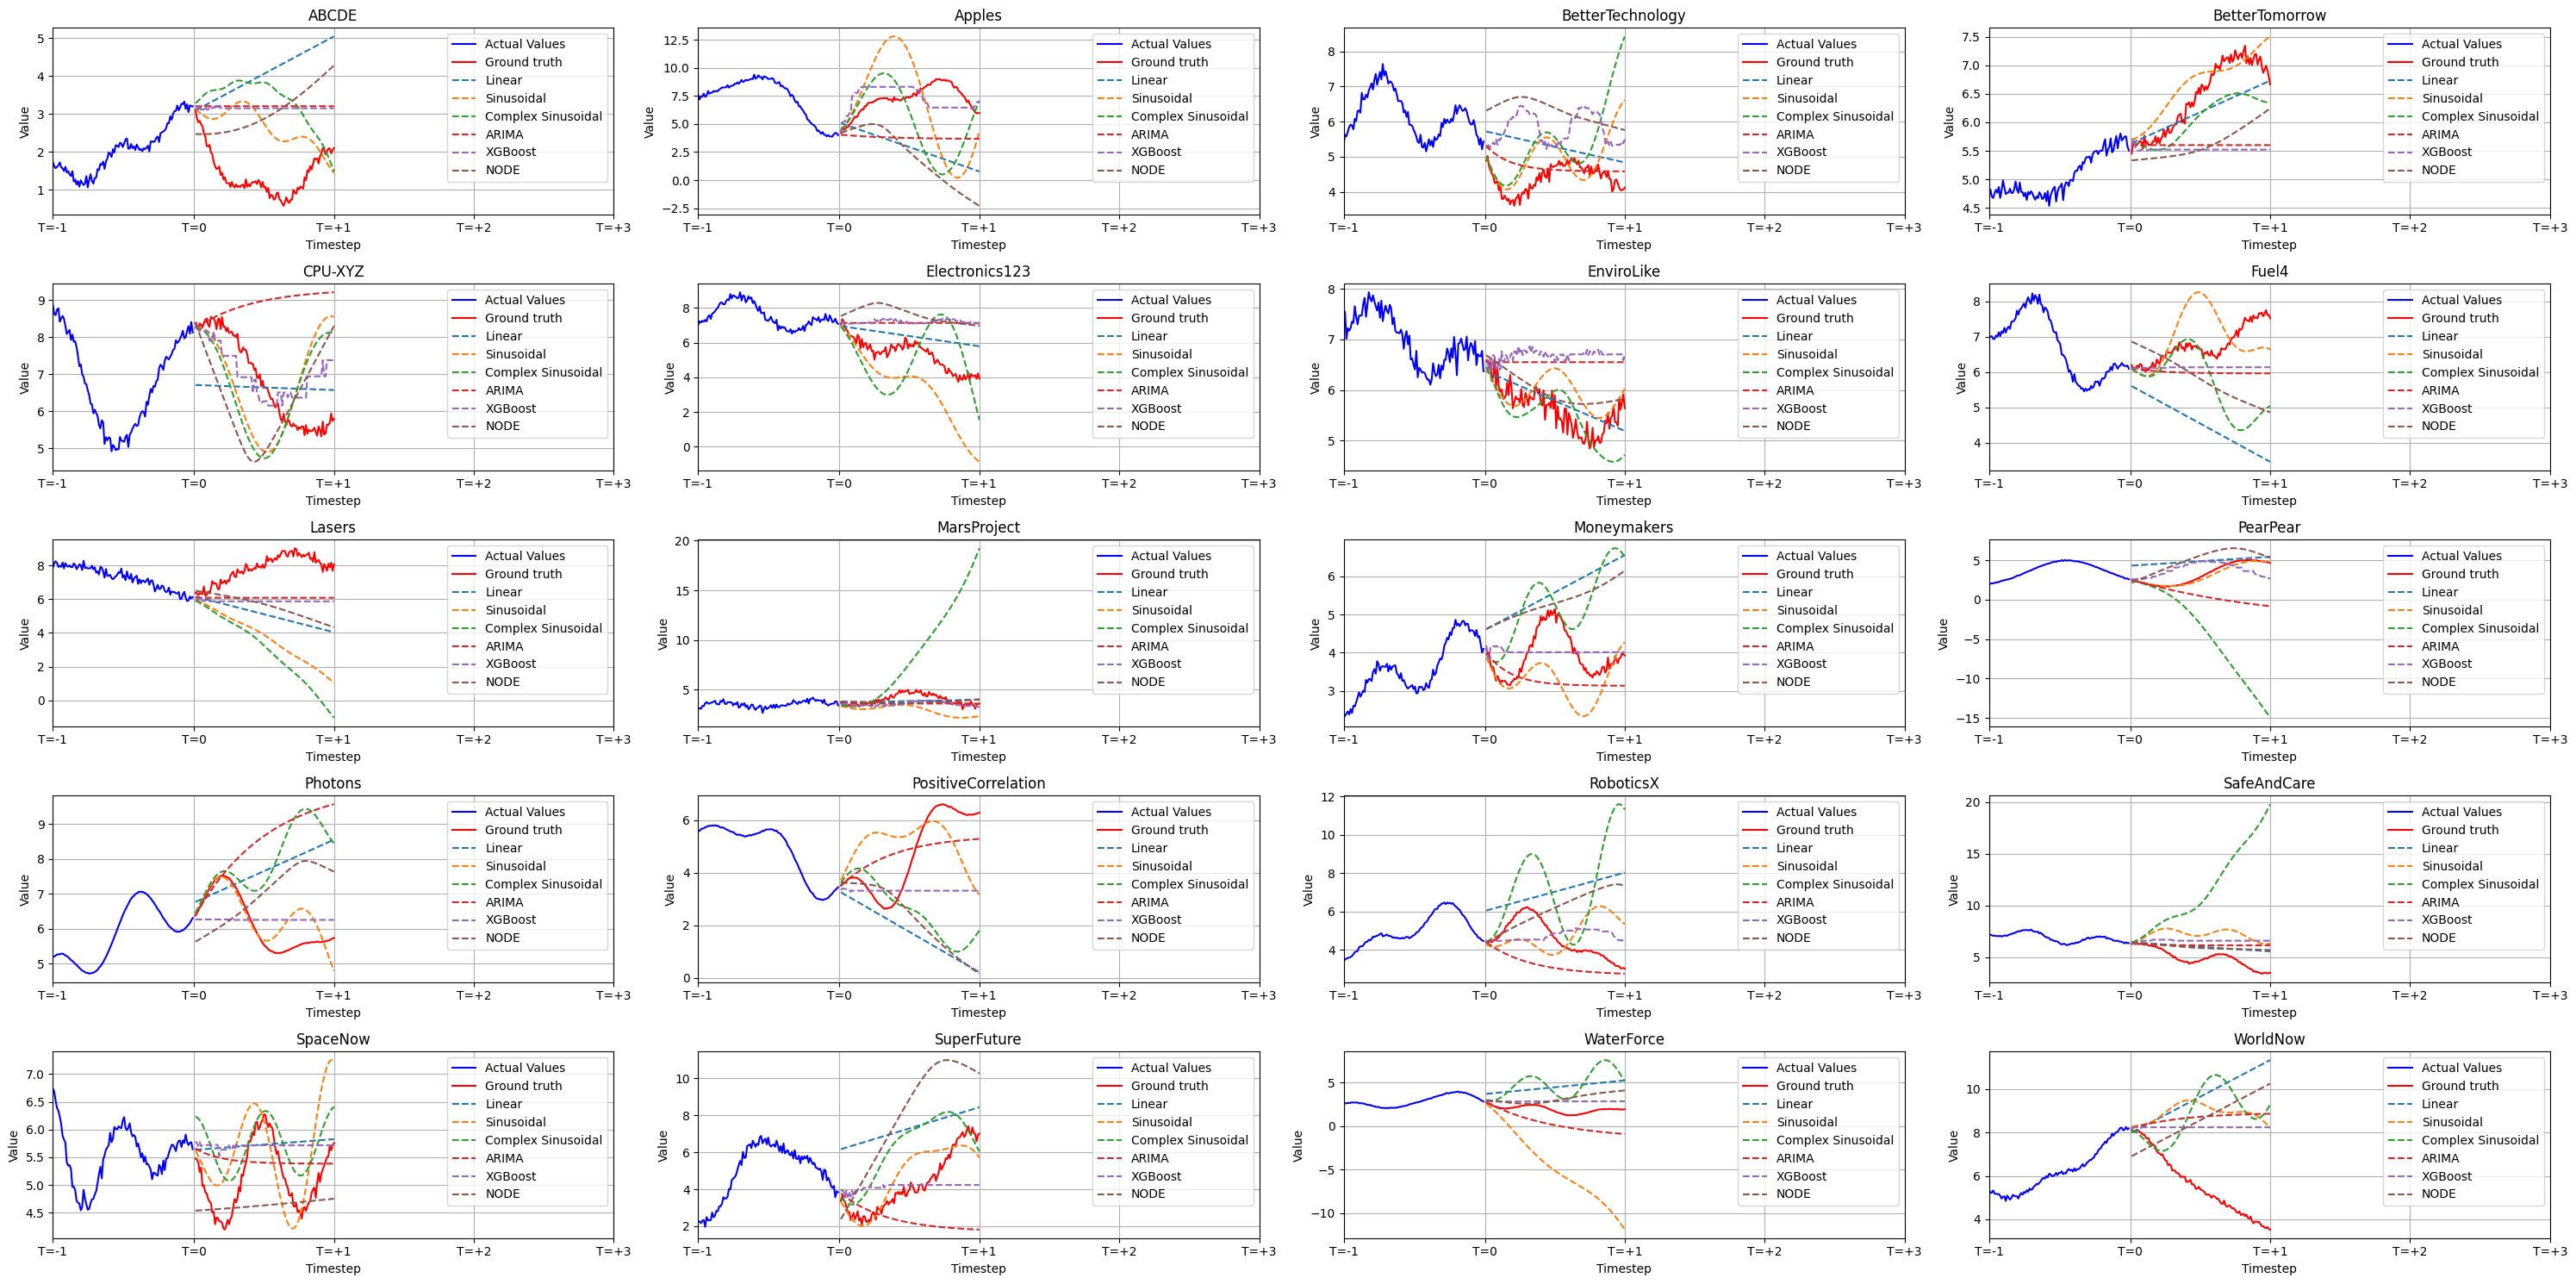

In [14]:
RMC = RegressionModelsCombined(old_data, window_size=50)
RMC.plot_multiple_predictions(val_range=201, predictions_list=[ground_truth] + regression_predictions, 
                              figsize=(30, 15), titles=["Ground truth"] + regression_models,)


In [44]:
def evaluate_predictions(ground_truth, predictions):
    results = {}
    
    for company, (_, actual_values) in ground_truth.items():
        if company not in predictions:
            continue  # Skip if no predictions available
        
        pred_indexes, pred = predictions[company]
        actual_values = np.array(actual_values)

        # Ensure the length matches (just in case)
        assert len(actual_values) == len(pred), f"Length mismatch for {company}: {len(actual_values)} vs {len(pred)}"
        # print(pred.shape, actual_values.shape)

        # Trend Metrics
        mae = np.mean(np.abs(actual_values - pred))
        mse = np.mean((actual_values - pred) ** 2)
        rmse = np.sqrt(mse)
        mape = np.mean(np.abs((actual_values - pred) / actual_values)) * 100
        dtw_distance, _ = fastdtw(actual_values, pred, dist=2)

        # Final Value Metrics
        final_actual = actual_values[-1]
        final_pred = pred[-1]
        final_abs_diff = abs(final_actual - final_pred)
        final_rel_error = abs(final_actual - final_pred) / abs(final_actual) if final_actual != 0 else np.nan
        smape = 2 * abs(final_actual - final_pred) / (abs(final_actual) + abs(final_pred)) * 100

        # Store results
        results[company] = {
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "MAPE": mape,
            "DTW Distance": dtw_distance,
            "Final Absolute Diff": final_abs_diff,
            "Final Relative Error": final_rel_error,
            "SMAPE": smape
        }

    return results

In [61]:
evaluation_results = {}
for model_name, predictions in zip(regression_models, regression_predictions):
    evaluation_results[model_name] = evaluate_predictions(ground_truth, predictions)

In [68]:
def aggregate_results(model_results):
    df = pd.DataFrame(model_results).T  # Convert dict to DataFrame
    summary = df.agg(["mean", "median", "std"])
    return summary

In [69]:
aggregate_evaluation_results = {}
for model_name, predictions in zip(regression_models, regression_predictions):
    model_results = evaluate_predictions(ground_truth, predictions)
    aggregate_evaluation_results[model_name] = aggregate_results(model_results)

In [50]:
def rank_models(model_summaries):
    df = pd.concat(model_summaries, axis=1)  # Merge all models into a single DataFrame

    # Normalize each metric across models (Min-Max Scaling)
    df_norm = (df - df.min()) / (df.max() - df.min())

    # Assign ranks (lower is better for error metrics)
    ranks = df_norm.rank(method="min", ascending=True).loc["mean"]  # Use mean values for ranking

    return ranks.sort_values()

In [70]:
rank_models(aggregate_evaluation_results)

Sinusoidal          Final Relative Error    2.0
                    SMAPE                   2.0
XGBoost             MAPE                    2.0
Sinusoidal          Final Absolute Diff     2.0
                    DTW Distance            2.0
                    MAPE                    2.0
Complex Sinusoidal  Final Absolute Diff     2.0
Sinusoidal          MSE                     2.0
Complex Sinusoidal  Final Relative Error    2.0
NODE                MSE                     2.0
Linear              MAPE                    2.0
ARIMA               SMAPE                   2.0
Linear              MSE                     2.0
Complex Sinusoidal  MSE                     2.0
XGBoost             RMSE                    3.0
                    MSE                     3.0
                    MAE                     3.0
                    DTW Distance            3.0
Linear              MAE                     3.0
XGBoost             Final Relative Error    3.0
ARIMA               Final Relative Error

In [ ]:
def plot_error_distribution(all_models_results, metric="RMSE"):
    data = []
    for model, results in all_models_results.items():
        for company, metrics in results.items():
            data.append({"Model": model, "Company": company, metric: metrics[metric]})
    
    df = pd.DataFrame(data)
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Model", y=metric, data=df)
    plt.yscale("log")  # If metric values vary widely
    plt.title(f"{metric} Distribution Across Companies")
    plt.xticks(rotation=45)
    plt.show()

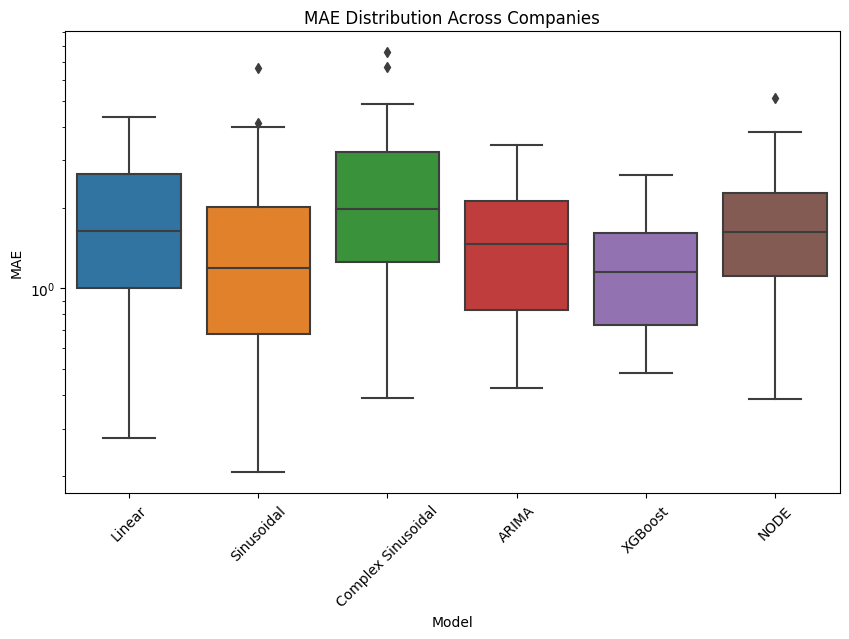

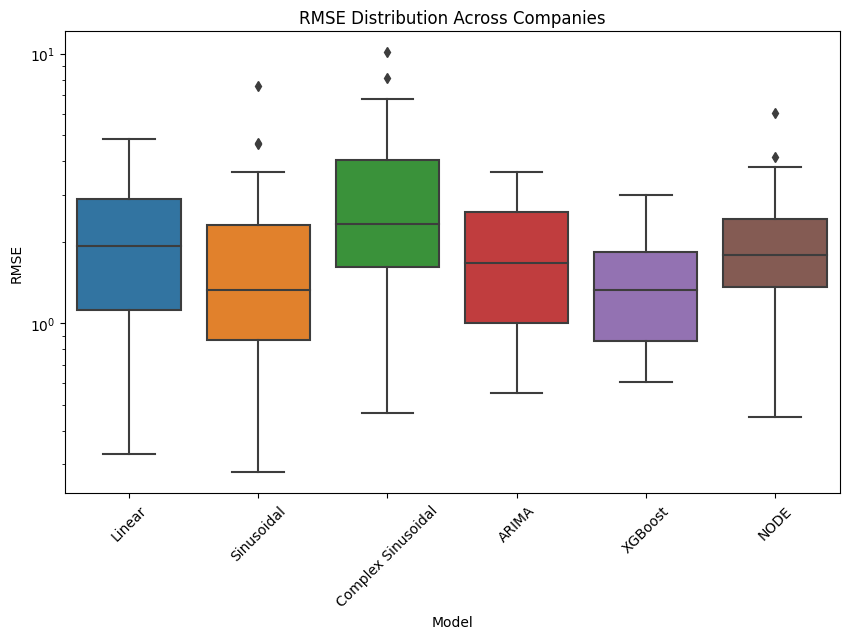

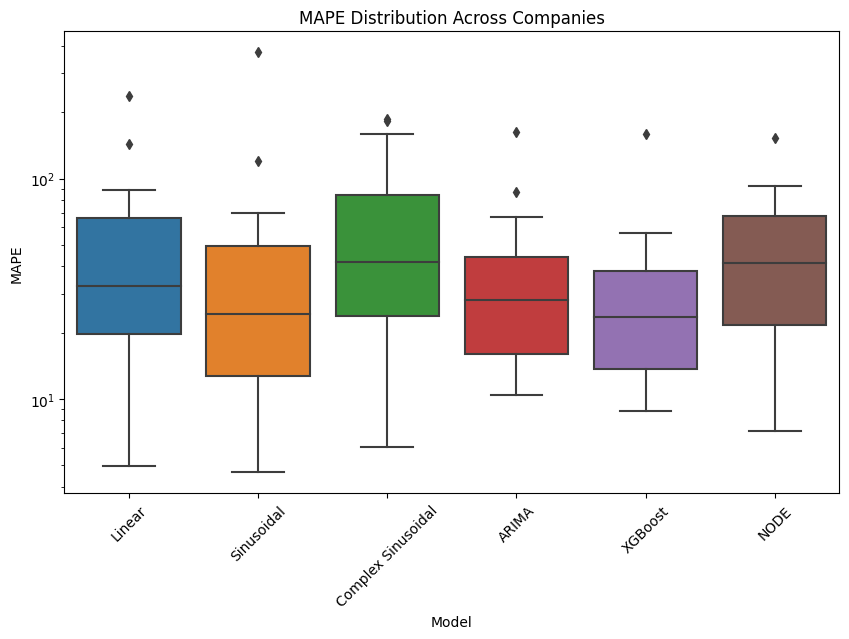

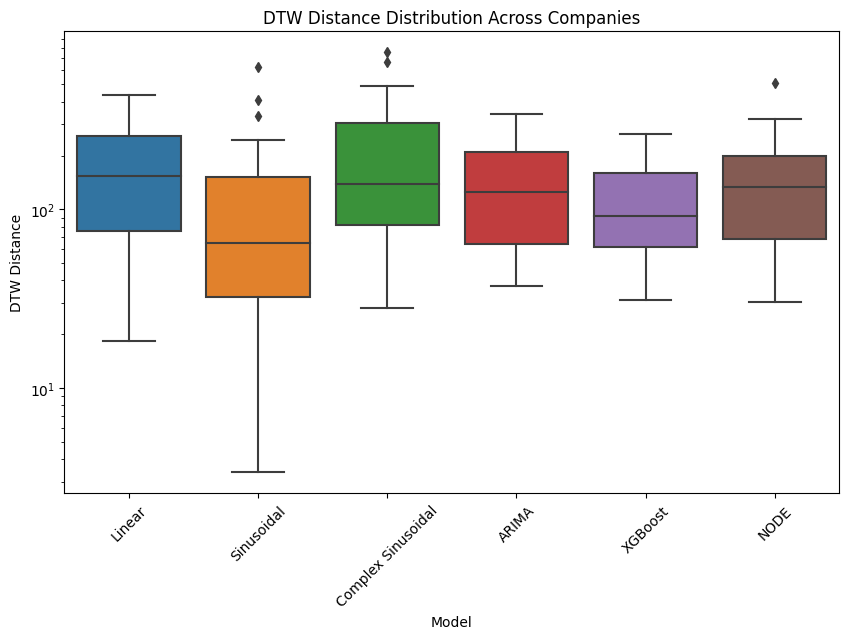

In [ ]:
for metric in ["MAE", "RMSE", "MAPE", "DTW Distance"]:
    plot_error_distribution(evaluation_results, metric=metric)

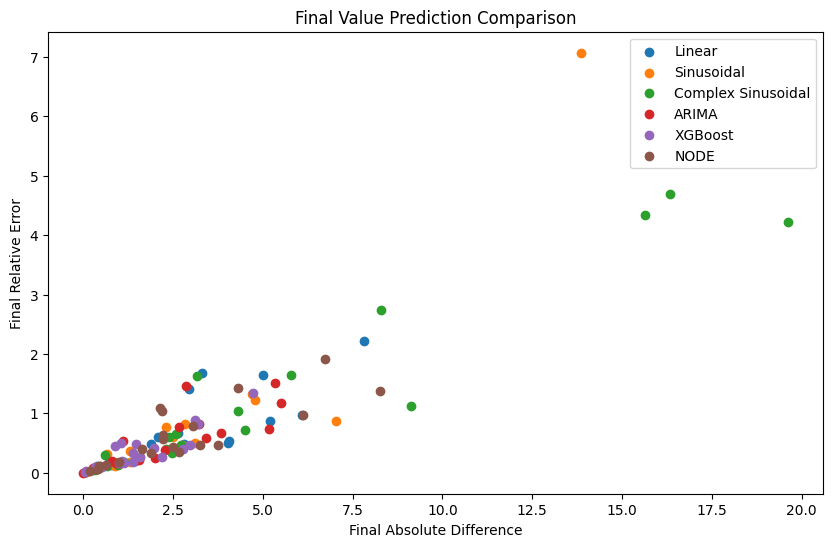

In [66]:
def plot_final_value_comparison(all_models_results):
    plt.figure(figsize=(10, 6))
    
    for model, results in all_models_results.items():
        actuals, preds = [], []
        for company, metrics in results.items():
            actuals.append(metrics["Final Absolute Diff"])
            preds.append(metrics["Final Relative Error"])
        
        plt.scatter(actuals, preds, label=model)

    plt.xlabel("Final Absolute Difference")
    plt.ylabel("Final Relative Error")
    plt.legend()
    plt.title("Final Value Prediction Comparison")
    plt.show()

# Example usage:
plot_final_value_comparison(evaluation_results)

In [ ]:
import plotly.graph_objects as go

def plot_final_value_comparison(all_models_results):
    fig = go.Figure()

    for model, results in all_models_results.items():
        actuals, preds = [], []
        for company, metrics in results.items():
            actuals.append(metrics["Final Absolute Diff"])
            preds.append(metrics["Final Relative Error"])
        
        # Create scatter for each model
        fig.add_trace(go.Scatter(
            x=actuals, 
            y=preds, 
            mode='markers',
            name=model,
            marker=dict(size=8),
            text=[company for company in results.keys()],  # Adding company names for hover info
            hovertemplate=
            "<b>%{text}</b><br>" +
            "Absolute Difference: %{x}<br>" +
            "Relative Error: %{y}<br>" +
            "<extra></extra>"
        ))

    fig.update_layout(
        title="Final Value Prediction Comparison",
        xaxis_title="Final Absolute Difference",
        yaxis_title="Final Relative Error",
        showlegend=True,
        hovermode="closest",  # Highlight nearest point when hovering
        template="plotly_dark"  # Optional: Apply a dark theme
    )

    fig.show()

# Example usage:
plot_final_value_comparison(evaluation_results)